In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from collections import Counter, defaultdict
import openpyxl

DB = '../data/humans_clean.sqlite3'
MPD_FILE = '../data/mpd2020.xlsx'

MIN_SCIENTISTS_PER_BIN = 5
TOP_N = 10


def shannon_entropy_from_counts(counts_dict, top_keys):
    """Compute Shannon entropy (bits) over the top_keys occupations."""
    vals = [counts_dict.get(k, 0) for k in top_keys]
    total = sum(vals)
    if total == 0:
        return np.nan
    probs = np.array([v / total for v in vals if v > 0])
    return -np.sum(probs * np.log2(probs))


def per_bin_entropy(bin_sci, top_n=10):
    """For each bin, pick the top-N occupations *in that bin* and compute entropy."""
    top10 = [o for o, _ in bin_sci.most_common(top_n)]
    return shannon_entropy_from_counts(bin_sci, top10), top10


# Load the set of occupation names classified as 'scientist' in the database
conn = sqlite3.connect(DB)
_cur = conn.execute("SELECT DISTINCT lower(name_en) FROM occupations WHERE meta_occupation = 'scientist'")
SCIENTIFIC_OCCUPATIONS = set(row[0] for row in _cur.fetchall())
conn.close()

print(f'Loaded {len(SCIENTIFIC_OCCUPATIONS)} scientific occupation labels')

Loaded 1729 scientific occupation labels


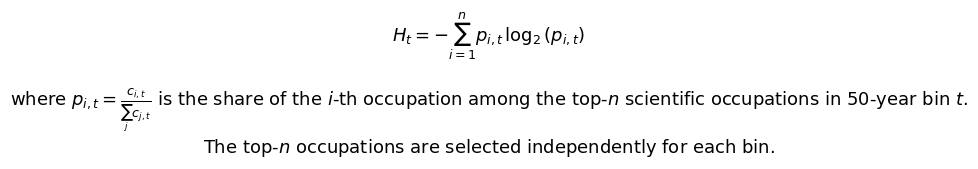

In [2]:
# ── Shannon entropy formula ──

fig, ax = plt.subplots(figsize=(8, 1.8))
ax.axis('off')

eq = (
    r"$H_t = -\sum_{i=1}^{n} p_{i,t} \, \log_2(p_{i,t})$"
    "\n\n"
    r"where $p_{i,t} = \frac{c_{i,t}}{\sum_j c_{j,t}}$ is the share of the $i$-th occupation"
    r" among the top-$n$ scientific occupations in 50-year bin $t$."
    "\n"
    r"The top-$n$ occupations are selected independently for each bin."
)

ax.text(0.5, 0.5, eq, fontsize=13, ha='center', va='center',
        transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [3]:
# ── Load Maddison Project Database 2020 GDP per capita ──

wb = openpyxl.load_workbook(MPD_FILE, read_only=True)
ws = wb['Full data']

gdp_data = {}  # {country_code: {year: gdppc}}
for row in ws.iter_rows(min_row=2, values_only=True):
    code, country, year, gdppc, pop = row
    if gdppc is not None and gdppc != '' and year is not None:
        year = int(year)
        if code not in gdp_data:
            gdp_data[code] = {}
        gdp_data[code][year] = float(gdppc)

wb.close()

print('GDP data loaded for', len(gdp_data), 'countries')
for code in ['GBR', 'ITA', 'DEU', 'CHE', 'TUR', 'FRA']:
    if code in gdp_data:
        years = sorted(gdp_data[code].keys())
        print(f'  {code}: {years[0]}\u2013{years[-1]} ({len(years)} observations)')

GDP data loaded for 169 countries
  GBR: 1000–2018 (768 observations)
  ITA: 1–2018 (710 observations)
  DEU: 1500–2018 (176 observations)
  CHE: 1–2018 (169 observations)
  TUR: 1–2018 (109 observations)
  FRA: 1–2018 (710 observations)


In [4]:
# ── Compute scientific complexity for polities ──
#
# Scientific complexity = Shannon entropy of the PER-BIN top-10 scientific
# occupations in 50-year bins (only bins with >= 5 scientists are kept).
# The top-10 are selected independently for each bin, reflecting
# the actual diversity within that time period.

polities = [
    ('Kingdom of England',  "(c.polity_name LIKE '%Kingdom of England%')",  'GBR'),
    ('Republic of Venice',  "(c.polity_name LIKE 'Republic of Venice%')",   'ITA'),
    ('Holy Roman Empire',   "(c.polity_name LIKE '%Holy Roman Empire%')",   'DEU'),
    ('Swiss Confederation', "(c.polity_name LIKE 'Swiss Confederation%')",  'CHE'),
    ('Ottoman Empire',      "(c.polity_name LIKE 'Ottoman Empire%')",       'TUR'),
    ('Kingdom of France',   "(c.polity_name LIKE '%Kingdom of France%')",   'FRA'),
]

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

results = []

for title, where, gdp_code in polities:
    cur = conn.execute(f'''
        SELECT MIN(c.impact_year), MAX(c.impact_year)
        FROM consolidate c
        WHERE {where} AND c.impact_year IS NOT NULL
    ''')
    yr_start, yr_end = cur.fetchone()

    cur = conn.execute(f'''
        SELECT c.occupations, c.impact_year
        FROM consolidate c
        WHERE {where}
          AND c.occupations IS NOT NULL
          AND c.impact_year IS NOT NULL
          AND c.is_scientist = 1
    ''')

    bin_sci = defaultdict(Counter)
    bin_n = defaultdict(int)
    n_rows = 0
    for occs_str, year in cur:
        if not occs_str:
            continue
        t = ((year + 25) // 50) * 50
        has_sci_occ = False
        for occ in occs_str.split('; '):
            occ = occ.strip().lower()
            if not occ or occ not in SCIENTIFIC_OCCUPATIONS:
                continue
            bin_sci[t][occ] += 1
            has_sci_occ = True
        if has_sci_occ:
            bin_n[t] += 1
        n_rows += 1

    # Keep only complete bins with enough scientists
    complete_bins = sorted(b for b in bin_sci
                           if b - 25 >= yr_start and b + 24 <= yr_end
                           and bin_n[b] >= MIN_SCIENTISTS_PER_BIN)

    # Per-bin top-10 entropy
    h_sci = []
    bin_top10 = {}
    for b in complete_bins:
        h, top10 = per_bin_entropy(bin_sci[b], TOP_N)
        h_sci.append(h)
        bin_top10[b] = top10

    # Average GDP per capita within each 50-year bin window
    gdp_bins = []
    gdp_vals = []
    if gdp_code in gdp_data:
        country_gdp = gdp_data[gdp_code]
        for b in complete_bins:
            bin_gdp = [v for y, v in country_gdp.items()
                       if b - 25 <= y <= b + 24]
            if bin_gdp:
                gdp_bins.append(b)
                gdp_vals.append(np.mean(bin_gdp))

    print(f'{title} ({yr_start}\u2013{yr_end}): {n_rows:,} scientists, '
          f'{len(complete_bins)} entropy bins, {len(gdp_bins)} GDP bins')
    # Show top-10 for first and last bin
    if complete_bins:
        print(f'  Top-10 @ {complete_bins[0]}: {bin_top10[complete_bins[0]]}')
        print(f'  Top-10 @ {complete_bins[-1]}: {bin_top10[complete_bins[-1]]}')

    results.append({
        'title': title,
        'yr_start': yr_start,
        'yr_end': yr_end,
        'bins': complete_bins,
        'h_sci': h_sci,
        'bin_sci': dict(bin_sci),
        'bin_n': dict(bin_n),
        'bin_top10': bin_top10,
        'gdp_bins': gdp_bins,
        'gdp_vals': gdp_vals,
        'n_sci': n_rows,
    })

conn.close()

Kingdom of England (936–1708): 1,229 scientists, 12 entropy bins, 9 GDP bins
  Top-10 @ 1100: ['historian', 'theologian', 'chronicler', 'philosopher', 'astronomer', 'mathematician']
  Top-10 @ 1650: ['theologian', 'historian', 'mathematician', 'philosopher', 'university teacher', 'linguist', 'astronomer', 'teacher', 'botanist', 'academic']


Republic of Venice (735–1796): 744 scientists, 9 entropy bins, 9 GDP bins
  Top-10 @ 1350: ['university teacher', 'theologian', 'historian', 'astronomer', 'mathematician', 'chronicler']
  Top-10 @ 1750: ['historian', 'mathematician', 'philosopher', 'physicist', 'theologian', 'teacher', 'art historian', 'archaeologist', 'botanist', 'philologist']


Holy Roman Empire (923–1806): 8,555 scientists, 16 entropy bins, 5 GDP bins
  Top-10 @ 1000: ['historian', 'theologian', 'philosopher', 'chronicler', 'political scientist', 'teacher', 'mathematician', 'musicologist', 'music theorist']
  Top-10 @ 1750: ['theologian', 'university teacher', 'historian', 'teacher', 'philosopher', 'mathematician', 'botanist', 'pedagogue', 'physicist', 'naturalist']


Swiss Confederation (1459–2024): 11,021 scientists, 11 entropy bins, 4 GDP bins
  Top-10 @ 1500: ['theologian', 'historian', 'university teacher', 'chronicler', 'mathematician', 'catholic theologian', 'teacher', 'musicologist', 'music theorist', 'philosopher']
  Top-10 @ 2000: ['university teacher', 'historian', 'researcher', 'theologian', 'art historian', 'teacher', 'economist', 'philosopher', 'mathematician', 'sociologist']


Ottoman Empire (1305–1923): 1,919 scientists, 10 entropy bins, 7 GDP bins
  Top-10 @ 1400: ['historian', 'islamic jurist', 'scientist', 'ulema', 'geographer', 'astronomer', 'mathematician', 'teacher', 'philosopher', 'botanist']
  Top-10 @ 1850: ['teacher', 'islamic jurist', 'historian', 'school teacher', 'philologist', 'ulema', 'linguist', 'literary scholar', 'theologian', 'university teacher']


Kingdom of France (990–1847): 6,194 scientists, 16 entropy bins, 11 GDP bins
  Top-10 @ 1050: ['theologian', 'chronicler', 'philosopher', 'church historian', 'teacher', 'intellectual', 'historian']
  Top-10 @ 1800: ['botanist', 'historian', 'naturalist', 'university teacher', 'mathematician', 'chemist', 'archaeologist', 'teacher', 'physicist', 'philosopher']


In [5]:
# (removed — individual polity figures below replace this panel)

In [6]:
# ── Extract detailed per-bin occupation data for all polities ──
# Uses per-bin top-10: each bin gets its own top-10 occupations.

all_focus = [
    ('Kingdom of England',  "(c.polity_name LIKE '%Kingdom of England%')",  'GBR'),
    ('Republic of Venice',  "(c.polity_name LIKE 'Republic of Venice%')",   'ITA'),
    ('Holy Roman Empire',   "(c.polity_name LIKE '%Holy Roman Empire%')",   'DEU'),
    ('Swiss Confederation', "(c.polity_name LIKE 'Swiss Confederation%')",  'CHE'),
    ('Ottoman Empire',      "(c.polity_name LIKE 'Ottoman Empire%')",       'TUR'),
    ('Kingdom of France',   "(c.polity_name LIKE '%Kingdom of France%')",   'FRA'),
]

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

focus_data = {}

for title, where, gdp_code in all_focus:
    cur = conn.execute(f'''
        SELECT MIN(c.impact_year), MAX(c.impact_year)
        FROM consolidate c
        WHERE {where} AND c.impact_year IS NOT NULL
    ''')
    yr_start, yr_end = cur.fetchone()

    cur = conn.execute(f'''
        SELECT c.occupations, c.impact_year
        FROM consolidate c
        WHERE {where}
          AND c.occupations IS NOT NULL
          AND c.impact_year IS NOT NULL
          AND c.is_scientist = 1
    ''')

    bin_sci = defaultdict(Counter)
    bin_n = defaultdict(int)
    for occs_str, year in cur:
        if not occs_str:
            continue
        t = ((year + 25) // 50) * 50
        has_sci_occ = False
        for occ in occs_str.split('; '):
            occ = occ.strip().lower()
            if not occ or occ not in SCIENTIFIC_OCCUPATIONS:
                continue
            bin_sci[t][occ] += 1
            has_sci_occ = True
        if has_sci_occ:
            bin_n[t] += 1

    complete_bins = sorted(b for b in bin_sci
                           if b - 25 >= yr_start and b + 24 <= yr_end
                           and bin_n[b] >= MIN_SCIENTISTS_PER_BIN)

    # Per-bin top-10 entropy
    h_sci = []
    bin_top10 = {}
    for b in complete_bins:
        h, top10 = per_bin_entropy(bin_sci[b], TOP_N)
        h_sci.append(h)
        bin_top10[b] = top10

    # Collect the union of all top-10 occupations across bins (for stacked area)
    all_top_occs = Counter()
    for b in complete_bins:
        for occ in bin_top10[b]:
            all_top_occs[occ] += bin_sci[b][occ]
    display_top10 = [o for o, _ in all_top_occs.most_common(TOP_N)]

    # Build proportions using the display top-10
    proportions = {occ: [] for occ in display_top10}
    for b in complete_bins:
        total = sum(bin_sci[b].get(k, 0) for k in display_top10)
        for occ in display_top10:
            proportions[occ].append(bin_sci[b].get(occ, 0) / total if total > 0 else 0)

    # GDP
    gdp_bins, gdp_vals = [], []
    if gdp_code in gdp_data:
        country_gdp = gdp_data[gdp_code]
        for b in complete_bins:
            bin_gdp = [v for y, v in country_gdp.items()
                       if b - 25 <= y <= b + 24]
            if bin_gdp:
                gdp_bins.append(b)
                gdp_vals.append(np.mean(bin_gdp))

    focus_data[title] = {
        'yr_start': yr_start, 'yr_end': yr_end,
        'bins': complete_bins, 'h_sci': h_sci,
        'bin_sci': dict(bin_sci), 'bin_n': dict(bin_n),
        'bin_top10': bin_top10,
        'display_top10': display_top10, 'proportions': proportions,
        'gdp_bins': gdp_bins, 'gdp_vals': gdp_vals,
    }

    print(f"{title}: {len(complete_bins)} bins, {len(gdp_bins)} GDP bins, display top-10 = {display_top10}")

conn.close()

Kingdom of England: 12 bins, 9 GDP bins, display top-10 = ['theologian', 'historian', 'philosopher', 'mathematician', 'university teacher', 'linguist', 'astronomer', 'bible translator', 'chronicler', 'academic']


Republic of Venice: 9 bins, 9 GDP bins, display top-10 = ['historian', 'philosopher', 'theologian', 'mathematician', 'university teacher', 'philologist', 'teacher', 'cartographer', 'astronomer', 'physicist']


Holy Roman Empire: 16 bins, 5 GDP bins, display top-10 = ['theologian', 'university teacher', 'historian', 'philosopher', 'teacher', 'mathematician', 'superintendent', 'secondary school teacher', 'astronomer', 'philologist']


Swiss Confederation: 11 bins, 4 GDP bins, display top-10 = ['university teacher', 'historian', 'theologian', 'teacher', 'art historian', 'botanist', 'mathematician', 'economist', 'researcher', 'chemist']


Ottoman Empire: 10 bins, 7 GDP bins, display top-10 = ['historian', 'teacher', 'islamic jurist', 'theologian', 'ulema', 'linguist', 'school teacher', 'philosopher', 'philologist', 'mathematician']


Kingdom of France: 16 bins, 11 GDP bins, display top-10 = ['historian', 'theologian', 'philosopher', 'mathematician', 'botanist', 'university teacher', 'cartographer', 'physicist', 'teacher', 'astronomer']


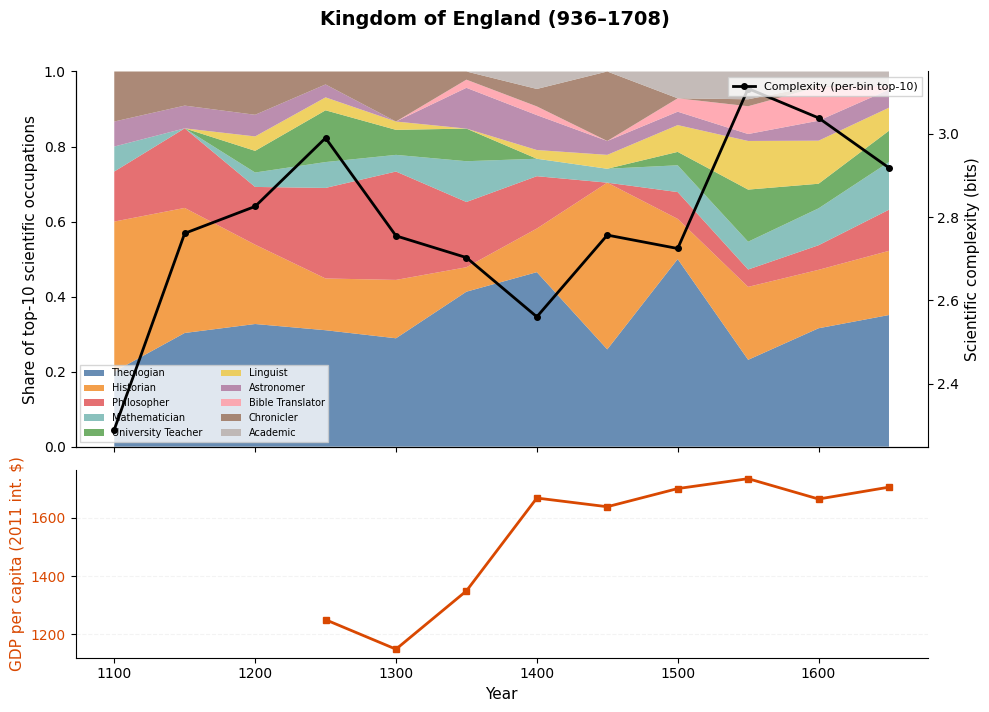

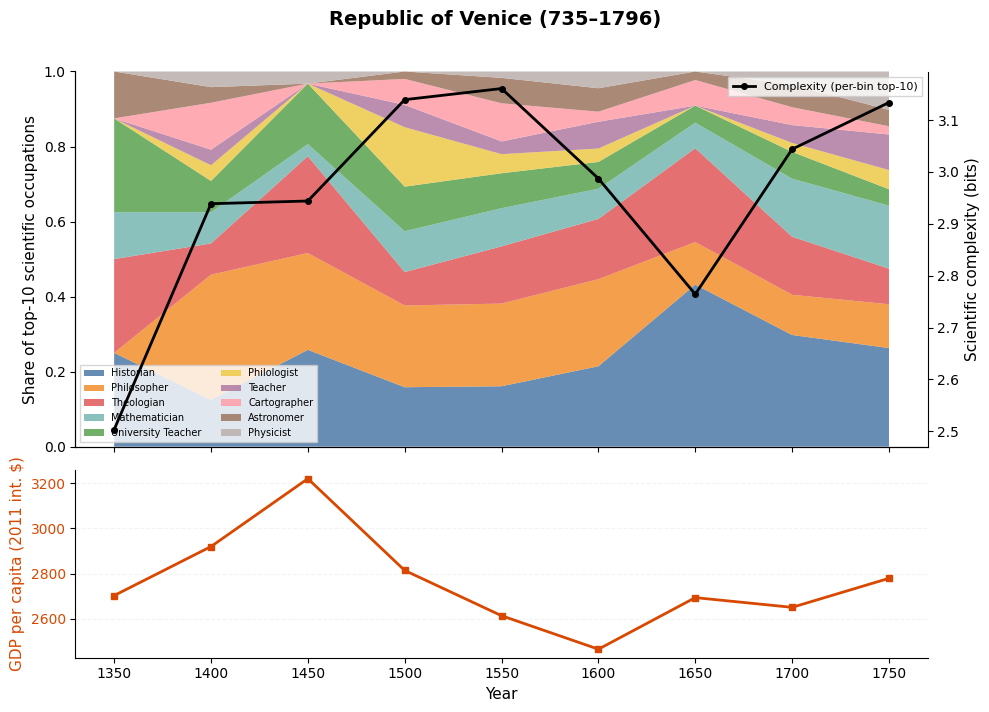

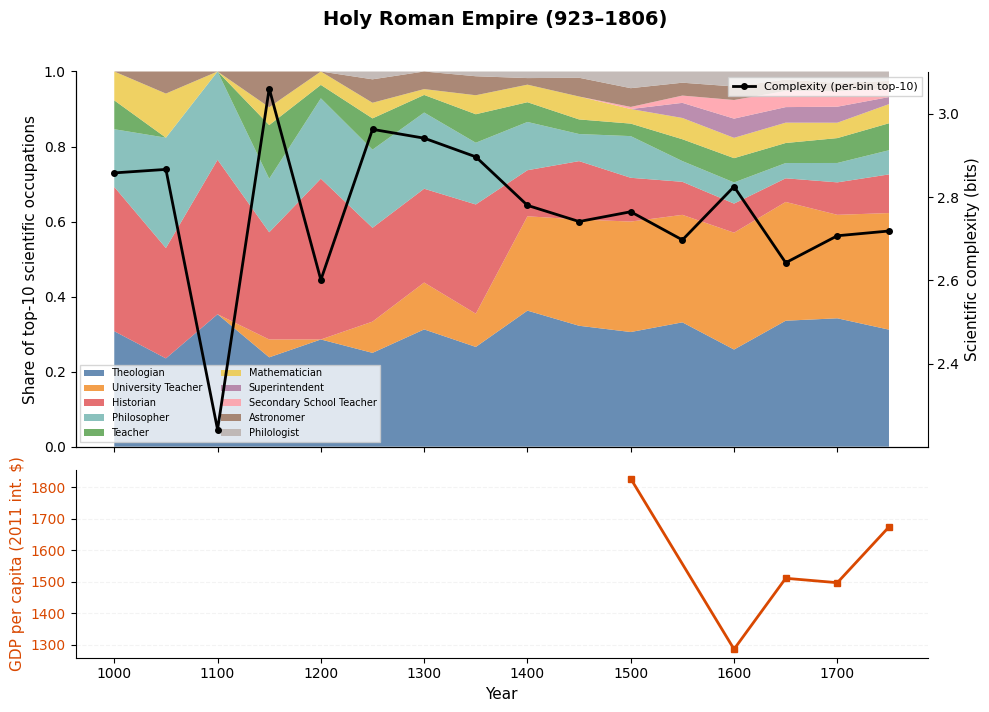

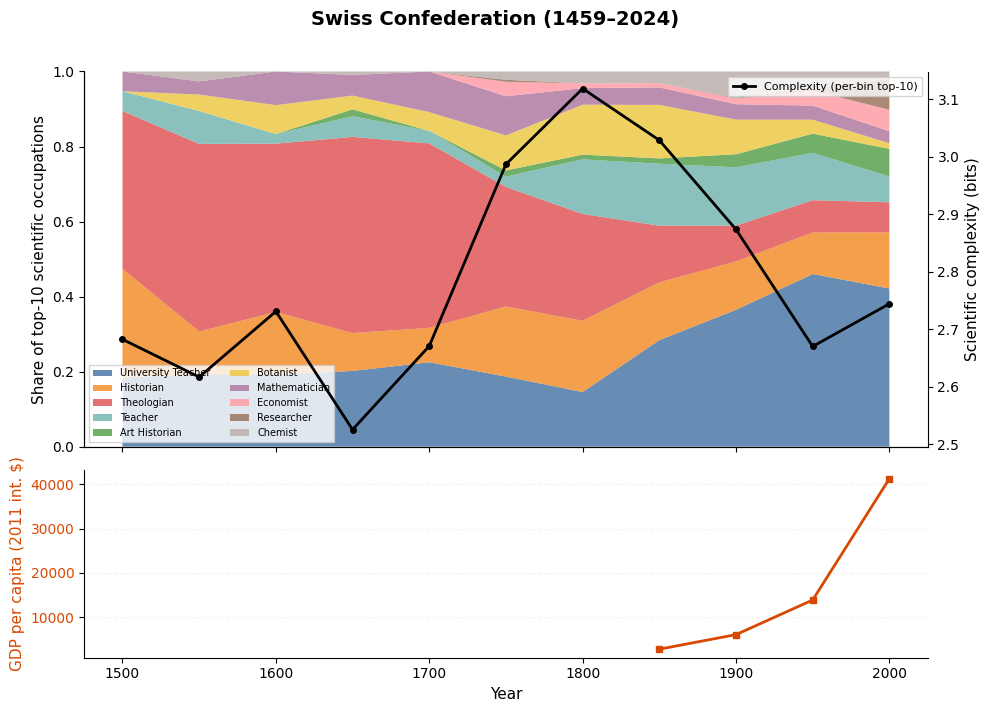

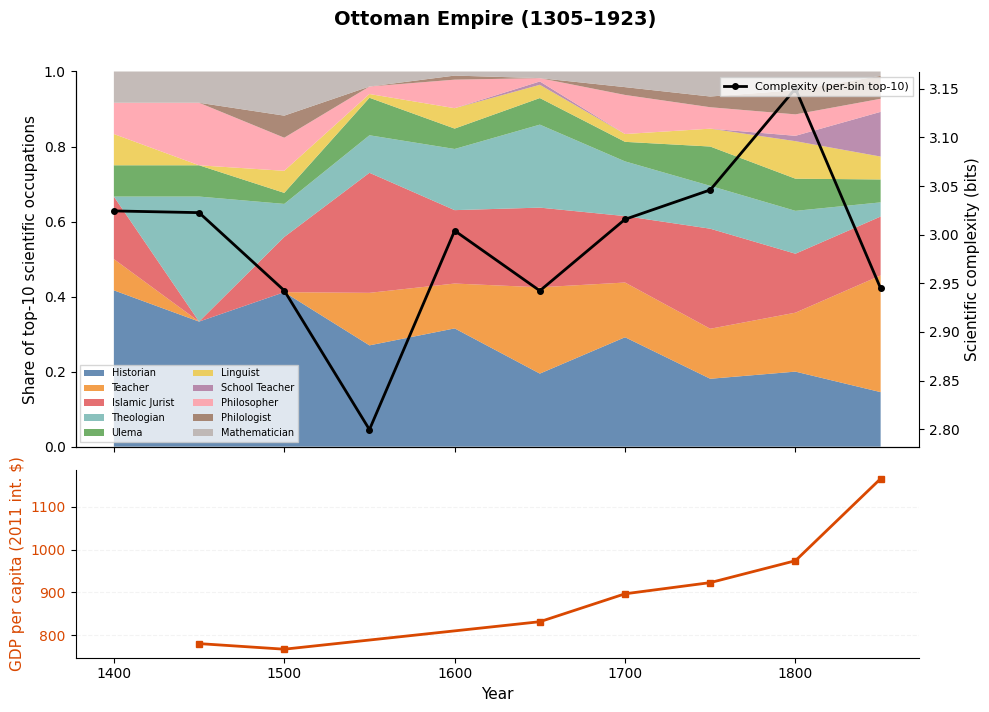

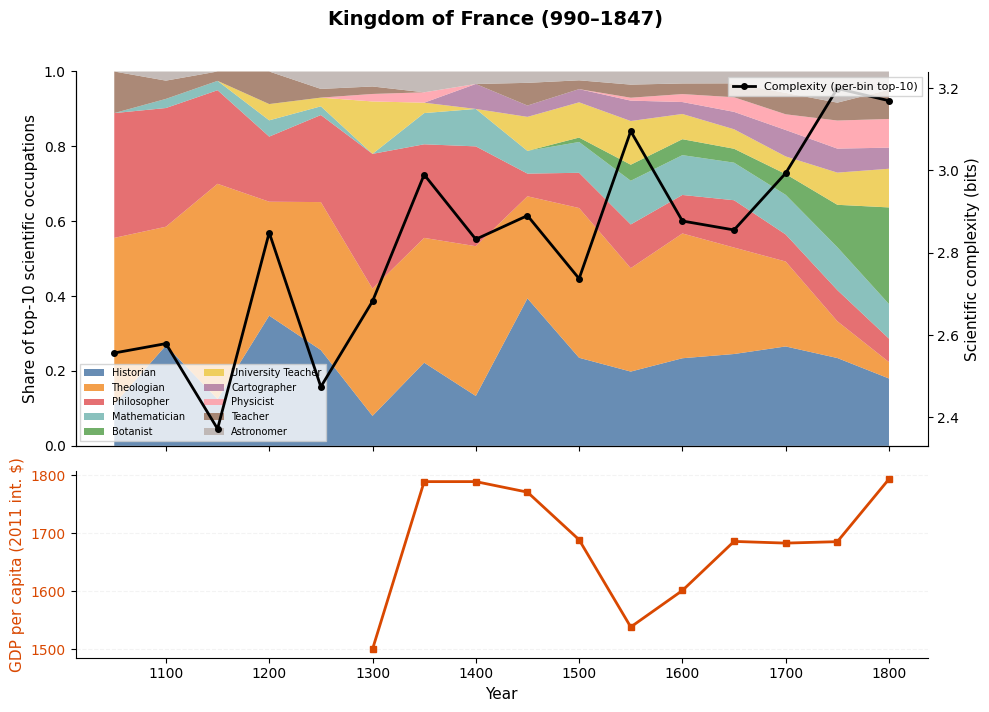

In [7]:
# ── All polities: occupation breakdown + entropy (top) / GDP per capita (bottom) ──

PALETTE = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
    '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac',
]

COLOR_GDP = '#d94801'

polity_order = [
    'Kingdom of England', 'Republic of Venice', 'Holy Roman Empire',
    'Swiss Confederation', 'Ottoman Empire', 'Kingdom of France',
]

for polity_name in polity_order:
    d = focus_data[polity_name]
    bins = d['bins']

    fig, (ax_occ, ax_gdp) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                          gridspec_kw={'height_ratios': [2, 1]})

    # ── Top panel: stacked occupations + entropy ──
    top10 = d['display_top10']
    y_stack = np.array([d['proportions'][occ] for occ in top10])

    ax_occ.stackplot(bins, y_stack, labels=[o.title() for o in top10],
                     colors=PALETTE, alpha=0.85)
    ax_occ.set_ylabel('Share of top-10 scientific occupations', fontsize=11)
    ax_occ.set_ylim(0, 1)
    ax_occ.tick_params(labelsize=10)
    ax_occ.spines['top'].set_visible(False)
    ax_occ.spines['right'].set_visible(False)

    ax_r = ax_occ.twinx()
    ax_r.plot(bins, d['h_sci'], '-o', color='black', linewidth=2,
              markersize=4, zorder=5, label='Complexity (per-bin top-10)')
    ax_r.set_ylabel('Scientific complexity (bits)', fontsize=11)
    ax_r.tick_params(labelsize=10)
    ax_r.spines['top'].set_visible(False)

    handles_occ, labels_occ = ax_occ.get_legend_handles_labels()
    ax_occ.legend(handles_occ, labels_occ, fontsize=7, loc='lower left',
                  ncol=2, frameon=True, fancybox=False, edgecolor='#cccccc')
    ax_r.legend(fontsize=8, loc='upper right', frameon=True,
                fancybox=False, edgecolor='#cccccc')

    # ── Bottom panel: GDP per capita ──
    if d['gdp_bins']:
        ax_gdp.plot(d['gdp_bins'], d['gdp_vals'], '-s', color=COLOR_GDP,
                    linewidth=2, markersize=5)
    ax_gdp.set_ylabel('GDP per capita (2011 int. $)', fontsize=11,
                       color=COLOR_GDP)
    ax_gdp.set_xlabel('Year', fontsize=11)
    ax_gdp.tick_params(axis='y', labelcolor=COLOR_GDP, labelsize=10)
    ax_gdp.tick_params(axis='x', labelsize=10)
    ax_gdp.spines['top'].set_visible(False)
    ax_gdp.spines['right'].set_visible(False)
    ax_gdp.grid(axis='y', alpha=0.15, linestyle='--')

    fig.suptitle(f"{polity_name} ({d['yr_start']}\u2013{d['yr_end']})",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()